  1. ЗАГРУЗКА ДАННЫХ
Форма датасета: (300, 3)

Первые 5 строк:
      x1    x2  class
0  11.25  5.05      1
1  10.95  4.70      1
2   9.85  5.80      1
3   9.80  5.75      1
4   9.15  6.80      1

Статистика:
               x1          x2       class
count  300.000000  300.000000  300.000000
mean    18.846500   17.188500    1.943333
std      8.253238    5.855957    0.822015
min      4.700000    3.650000    1.000000
25%     11.287500   13.687500    1.000000
50%     19.100000   16.550000    2.000000
75%     26.250000   19.562500    3.000000
max     33.050000   31.750000    3.000000

Распределение истинных классов:
class
1    110
2     97
3     93
Name: count, dtype: int64

  2. K-MEANS (k=3)
Алгоритм сошёлся за 3 итераций
Инерция (SSE): 8957.91

Центроиды кластеров:
  Кластер 1: x1=19.118, x2=29.377
  Кластер 2: x1=11.006, x2=15.733
  Кластер 3: x1=26.561, x2=15.631

Размеры кластеров:
  Кластер 1: 33 объектов
  Кластер 2: 133 объектов
  Кластер 3: 134 объектов


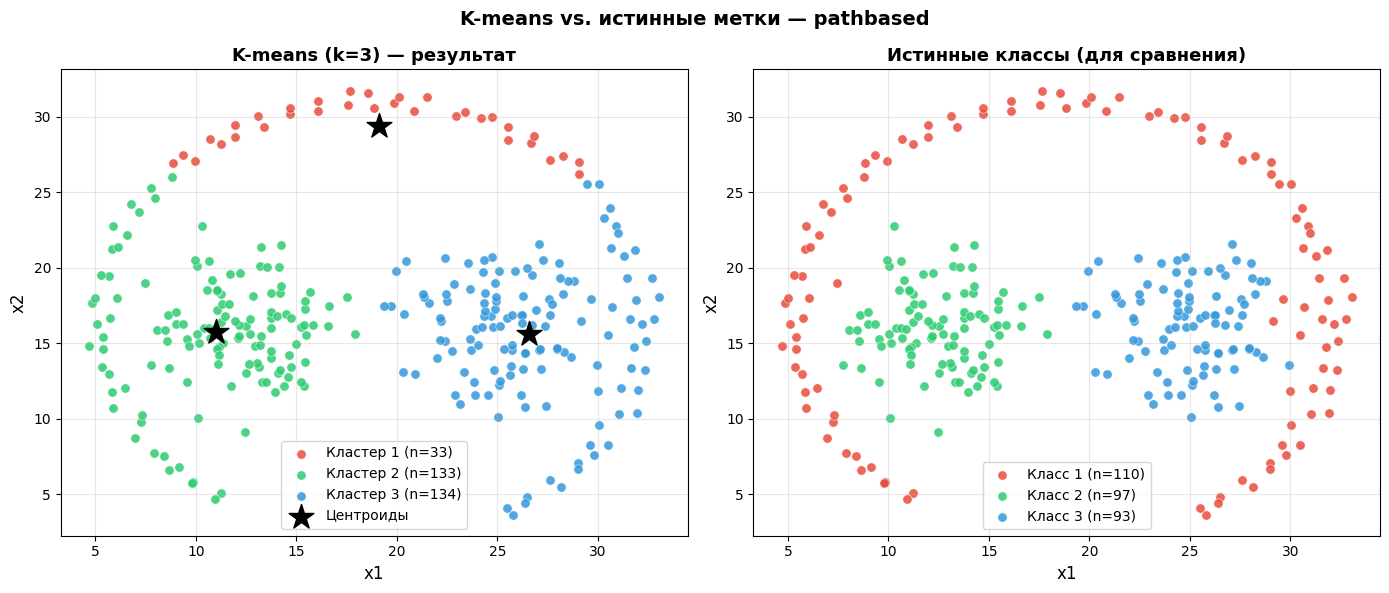

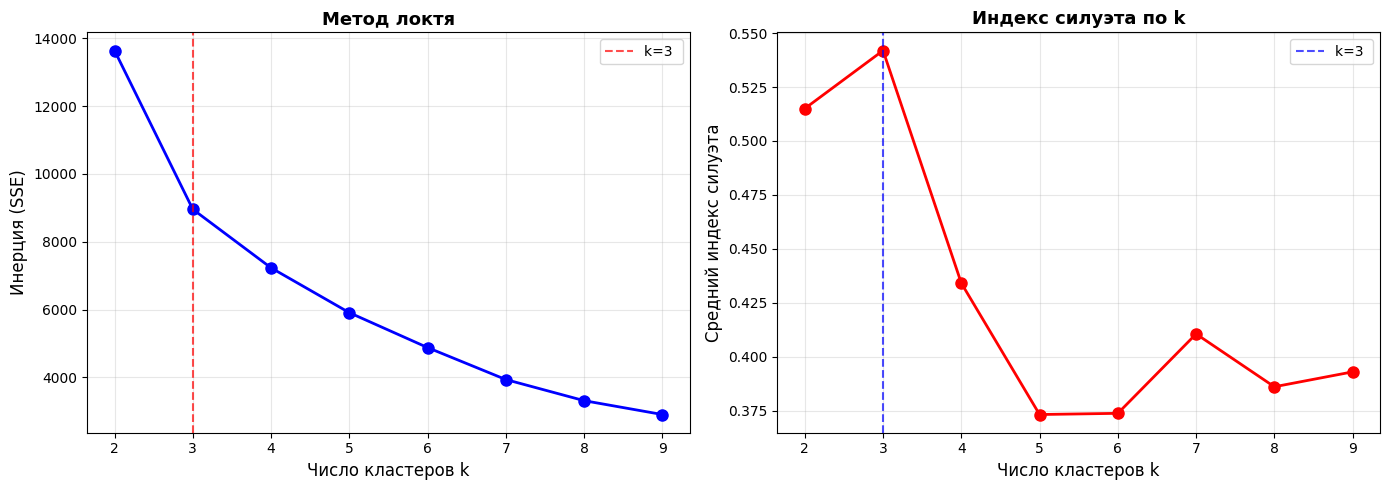


Значения силуэта по k:
  k=2: 0.5150
  k=3: 0.5419 <-- 
  k=4: 0.4341
  k=5: 0.3731
  k=6: 0.3737
  k=7: 0.4105
  k=8: 0.3860
  k=9: 0.3929

  3. КЛАСТЕРНЫЕ СИЛУЭТЫ


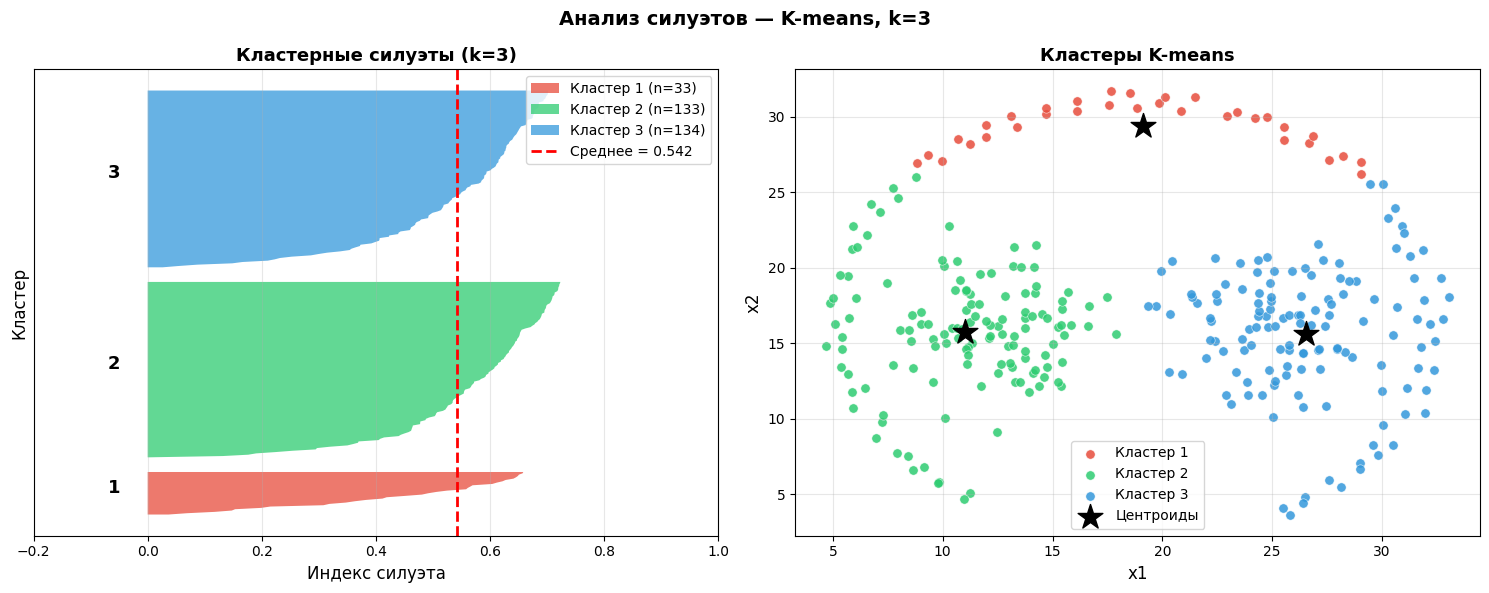


  ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ
  Средний индекс силуэта: 0.5419
  Инерция (SSE):          8957.91

  => Качество кластеризации: ХОРОШАЯ (0.50–0.70)

  Силуэты по кластерам:
    Кластер 1: среднее=0.4412, мин=0.0364, макс=0.6582, n=33
    Кластер 2: среднее=0.5693, мин=-0.0022, макс=0.7232, n=133
    Кластер 3: среднее=0.5395, мин=0.0262, макс=0.7018, n=134


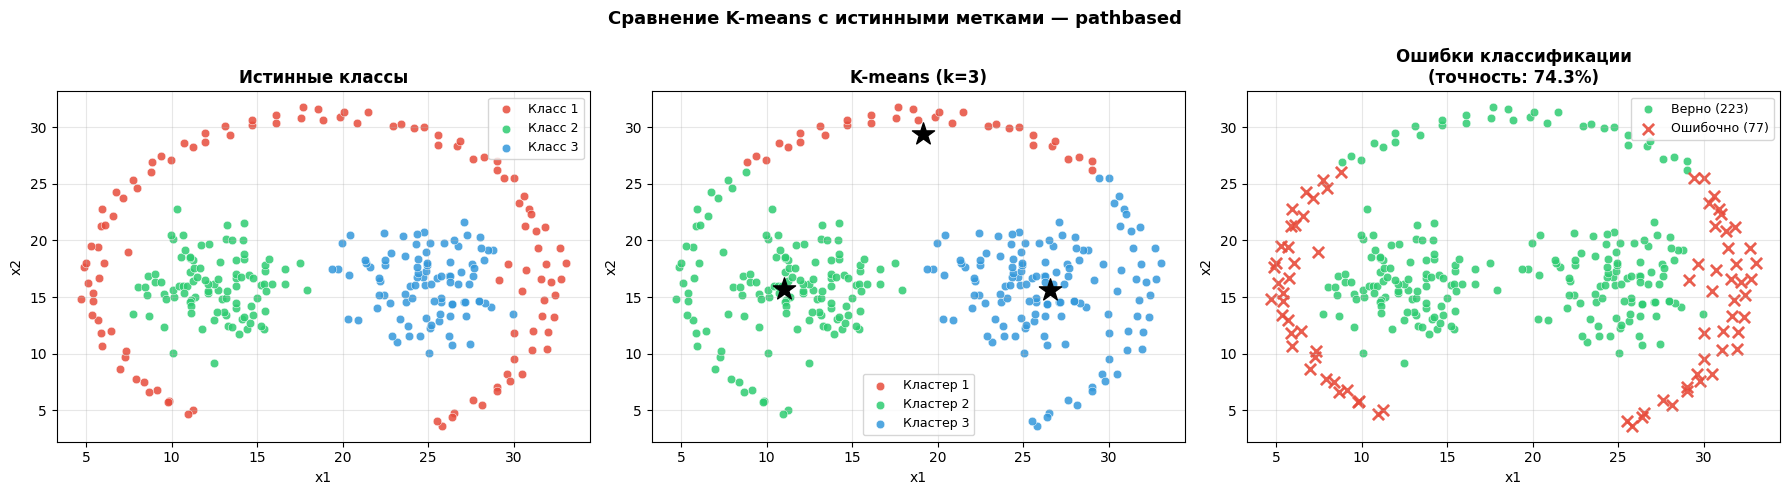


Верно классифицировано: 223/300 (74.3%)


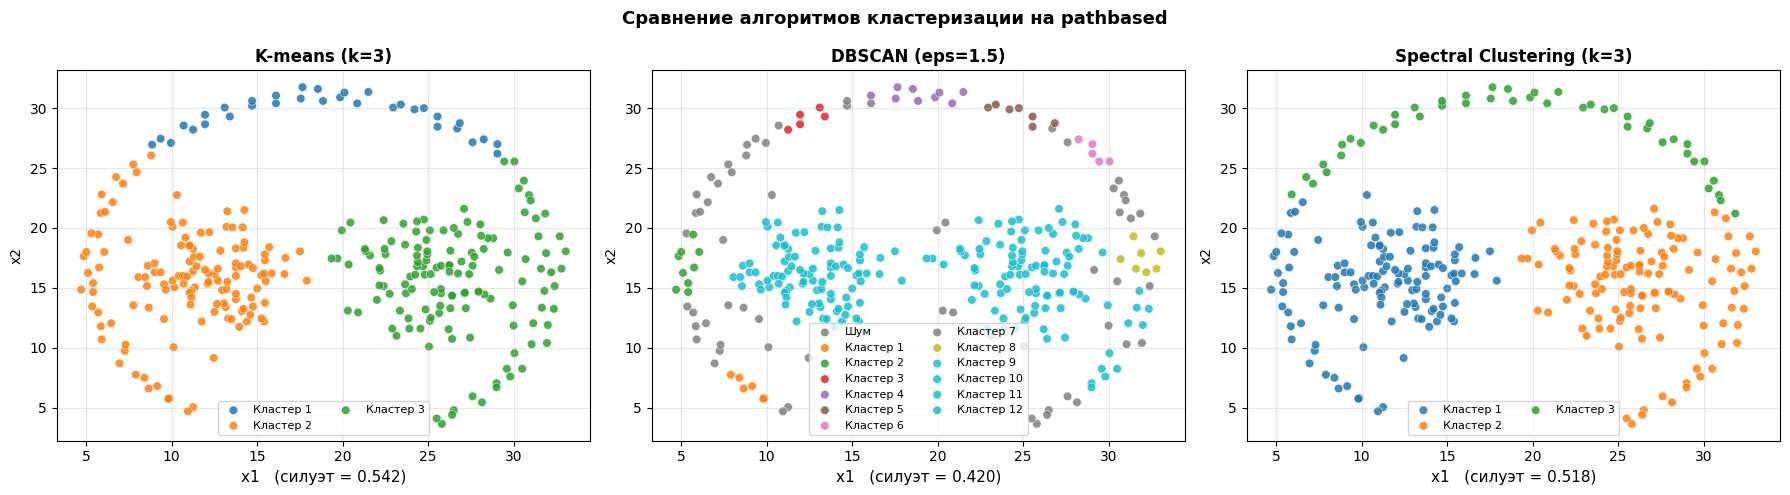

In [ ]:
"""
Кластерный анализ методом K-means
Датасет: pathbased.csv
Вариант 6: число кластеров k = 3
"""

# Импорт необходимых библиотек
import pandas as pd                      # Для работы с данными в табличном формате
import numpy as np                       # Для математических операций и работы с массивами
import matplotlib.pyplot as plt          # Для построения графиков и визуализации
from sklearn.cluster import KMeans       # Алгоритм K-means кластеризации
from sklearn.metrics import silhouette_score, silhouette_samples  # Метрики качества кластеризации
from scipy.optimize import linear_sum_assignment  # Для сопоставления кластеров с истинными метками
import warnings                           # Для управления предупреждениями
warnings.filterwarnings('ignore')         # Отключаем вывод предупреждений для чистоты вывода

# ============================================================
# 1. ЗАГРУЗКА И ИЗУЧЕНИЕ ДАННЫХ
# ============================================================
print("=" * 60)
print("  1. ЗАГРУЗКА ДАННЫХ")
print("=" * 60)

# Загружаем данные из CSV файла с разделителем точка с запятой
df = pd.read_csv('pathbased.csv', sep=';')

# Выводим размерность датасета (количество строк, столбцов)
print(f"Форма датасета: {df.shape}")

# Выводим первые 5 строк для ознакомления со структурой данных
print(f"\nПервые 5 строк:\n{df.head()}")

# Выводим статистику по каждому столбцу (среднее, мин, макс, квартили)
print(f"\nСтатистика:\n{df.describe()}")

# Выводим количество объектов в каждом истинном классе
print(f"\nРаспределение истинных классов:\n{df['class'].value_counts().sort_index()}")

# Извлекаем признаки x1 и x2 в виде numpy-массива (матрица объекты-признаки)
X = df[['x1', 'x2']].values

# Задаем число кластеров
K = 3

# Определяем цвета для кластеров (красный, зеленый, синий)
COLORS = ['#e74c3c', '#2ecc71', '#3498db']

# Определяем цвета для истинных классов (для визуального сравнения)
TRUE_COLORS = {1: '#e74c3c', 2: '#2ecc71', 3: '#3498db'}

# ============================================================
# 2. K-MEANS КЛАСТЕРИЗАЦИЯ (k=3)
# ============================================================
print("\n" + "=" * 60)
print("  2. K-MEANS (k=3)")
print("=" * 60)

# Создаем объект KMeans с заданными параметрами
kmeans = KMeans(
    n_clusters=K,           # Количество кластеров
    init='k-means++',       # Умная инициализация центроидов (ускоряет сходимость)
    n_init=20,              # Количество запусков с разными начальными центроидами
    max_iter=300,           # Максимальное количество итераций алгоритма
    random_state=42         # Фиксируем seed для воспроизводимости результатов
)

# Обучаем модель и получаем метки кластеров для каждого объекта
labels = kmeans.fit_predict(X)

# Получаем координаты центроидов (центров) кластеров
centers = kmeans.cluster_centers_

# Выводим количество итераций, за которое алгоритм сошелся
print(f"Алгоритм сошёлся за {kmeans.n_iter_} итераций")

# Выводим инерцию (сумму квадратов расстояний от точек до центроидов)
print(f"Инерция (SSE): {kmeans.inertia_:.2f}")

# Выводим координаты центроидов каждого кластера
print("\nЦентроиды кластеров:")
for i, c in enumerate(centers):
    print(f"  Кластер {i+1}: x1={c[0]:.3f}, x2={c[1]:.3f}")

# Выводим количество объектов в каждом кластере
print("\nРазмеры кластеров:")
for u, cnt in zip(*np.unique(labels, return_counts=True)):
    print(f"  Кластер {u+1}: {cnt} объектов")

# ============================================================
# 3. РАСКРАШЕННЫЕ ДИАГРАММЫ КЛАСТЕРОВ (СРАВНЕНИЕ)
# ============================================================

# Создаем фигуру с двумя подграфиками (1 строка, 2 колонки), размер 14x6 дюймов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Левый график: результат K-means ---
ax = axes[0]

# Перебираем каждый кластер
for i in range(K):
    # Создаем маску (логический индекс) для объектов, принадлежащих текущему кластеру
    mask = labels == i
    # Рисуем точки кластера: координаты x1, x2, цвет, метка, размер, прозрачность
    ax.scatter(X[mask, 0], X[mask, 1],
               c=COLORS[i], label=f'Кластер {i+1} (n={mask.sum()})',
               s=45, alpha=0.85, edgecolors='white', linewidths=0.4)

# Рисуем центроиды черными звездочками увеличенного размера
ax.scatter(centers[:, 0], centers[:, 1],
           c='black', marker='*', s=350, zorder=6, label='Центроиды')

# Устанавливаем заголовок для левого графика
ax.set_title(f'K-means (k={K}) — результат', fontsize=13, fontweight='bold')
# Подписи осей
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
# Включаем легенду
ax.legend(fontsize=10)
# Включаем сетку с прозрачностью 30%
ax.grid(True, alpha=0.3)

# --- Правый график: истинные классы (для сравнения) ---
ax2 = axes[1]

# Перебираем уникальные значения истинных классов (1, 2, 3)
for cls in sorted(df['class'].unique()):
    # Создаем маску для объектов текущего класса
    mask = df['class'] == cls
    # Рисуем точки истинных классов
    ax2.scatter(df.loc[mask, 'x1'], df.loc[mask, 'x2'],
                c=TRUE_COLORS[cls], label=f'Класс {cls} (n={mask.sum()})',
                s=45, alpha=0.85, edgecolors='white', linewidths=0.4)

# Устанавливаем заголовок для правого графика
ax2.set_title('Истинные классы (для сравнения)', fontsize=13, fontweight='bold')
ax2.set_xlabel('x1', fontsize=12)
ax2.set_ylabel('x2', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Общий заголовок для всей фигуры
plt.suptitle('K-means vs. истинные метки — pathbased', fontsize=14, fontweight='bold')

# Автоматическая настройка отступов между элементами
plt.tight_layout()

# Отображаем график в консоли (интерактивно)
plt.show()

# ============================================================
# 4. МЕТОД ЛОКТЯ И ИНДЕКС СИЛУЭТА (выбор оптимального k)
# ============================================================

# Создаем пустые списки для хранения инерции и силуэтных оценок
inertias, sil_scores = [], []

# Диапазон значений k от 2 до 9 (включительно)
k_range = range(2, 10)

# Перебираем все значения k
for k in k_range:
    # Создаем модель KMeans для текущего k
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    # Обучаем и получаем метки
    lbl = km.fit_predict(X)
    # Добавляем значение инерции в список
    inertias.append(km.inertia_)
    # Добавляем средний индекс силуэта в список
    sil_scores.append(silhouette_score(X, lbl))

# Создаем фигуру с двумя подграфиками (1 строка, 2 колонки), размер 14x5 дюймов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Левый график: метод локтя (инерция) ---
axes[0].plot(list(k_range), inertias, 'bo-', lw=2, ms=8)  # Синие круги с линией
axes[0].axvline(x=3, color='red', ls='--', alpha=0.7, label='k=3 ')  # Вертикальная линия для k=3
axes[0].set_xlabel('Число кластеров k', fontsize=12)
axes[0].set_ylabel('Инерция (SSE)', fontsize=12)
axes[0].set_title('Метод локтя', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(k_range))

# --- Правый график: индекс силуэта ---
axes[1].plot(list(k_range), sil_scores, 'ro-', lw=2, ms=8)  # Красные круги с линией
axes[1].axvline(x=3, color='blue', ls='--', alpha=0.7, label='k=3 ')
axes[1].set_xlabel('Число кластеров k', fontsize=12)
axes[1].set_ylabel('Средний индекс силуэта', fontsize=12)
axes[1].set_title('Индекс силуэта по k', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(k_range))

# Настраиваем отступы и отображаем график
plt.tight_layout()
plt.show()

# Выводим значения силуэта для каждого k в консоль
print("\nЗначения силуэта по k:")
for k, s in zip(k_range, sil_scores):
    tag = ' <-- ' if k == 3 else ''
    print(f"  k={k}: {s:.4f}{tag}")

# ============================================================
# 5. КЛАСТЕРНЫЕ СИЛУЭТЫ (график силуэтов для k=3)
# ============================================================
print("\n" + "=" * 60)
print("  3. КЛАСТЕРНЫЕ СИЛУЭТЫ")
print("=" * 60)

# Вычисляем силуэтные оценки для каждого объекта (s(i))
sample_sil = silhouette_samples(X, labels)

# Вычисляем средний индекс силуэта (среднее всех s(i))
avg_sil = silhouette_score(X, labels)

# Создаем фигуру с двумя подграфиками (1 строка, 2 колонки), размер 15x6 дюймов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Левый график: силуэтная диаграмма ---
# y_lower - начальная позиция по вертикали для первого кластера
y_lower = 10

# Перебираем каждый кластер
for i in range(K):
    # Получаем силуэтные оценки для объектов текущего кластера и сортируем их по возрастанию
    vals = np.sort(sample_sil[labels == i])
    # Вычисляем верхнюю границу для текущего кластера
    y_upper = y_lower + len(vals)

    # Закрашиваем область силуэта кластера
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                      facecolor=COLORS[i], alpha=0.75,
                      label=f'Кластер {i+1} (n={len(vals)})')

    # Подписываем номер кластера слева от его силуэта
    ax1.text(-0.07, y_lower + 0.5 * len(vals), str(i + 1),
             fontsize=13, fontweight='bold')

    # Сдвигаем нижнюю границу для следующего кластера
    y_lower = y_upper + 10

# Рисуем вертикальную линию на уровне среднего индекса силуэта
ax1.axvline(x=avg_sil, color='red', ls='--', lw=2,
            label=f'Среднее = {avg_sil:.3f}')

# Настройка левого графика
ax1.set_xlabel('Индекс силуэта', fontsize=12)
ax1.set_ylabel('Кластер', fontsize=12)
ax1.set_title(f'Кластерные силуэты (k={K})', fontsize=13, fontweight='bold')
ax1.set_xlim([-0.2, 1.0])  # Диапазон значений силуэта от -0.2 до 1.0
ax1.set_yticks([])         # Убираем метки по оси Y (заменены цифрами у каждого силуэта)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='x')  # Сетка только по вертикали

# --- Правый график: точечная диаграмма кластеров K-means ---
for i in range(K):
    mask = labels == i
    ax2.scatter(X[mask, 0], X[mask, 1],
                c=COLORS[i], label=f'Кластер {i+1}',
                s=45, alpha=0.85, edgecolors='white', linewidths=0.4)

# Рисуем центроиды поверх точек
ax2.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='*', s=350, zorder=6, label='Центроиды')

# Настройка правого графика
ax2.set_xlabel('x1', fontsize=12)
ax2.set_ylabel('x2', fontsize=12)
ax2.set_title('Кластеры K-means', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Общий заголовок для всей фигуры
plt.suptitle(f'Анализ силуэтов — K-means, k={K}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 6. ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ
# ============================================================
print("\n" + "=" * 60)
print("  ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ")
print("=" * 60)

# Выводим основные метрики качества
print(f"  Средний индекс силуэта: {avg_sil:.4f}")
print(f"  Инерция (SSE):          {kmeans.inertia_:.2f}")
print()

# Интерпретируем качество на основе индекса силуэта
if avg_sil > 0.70:
    quality = 'ОТЛИЧНАЯ (> 0.70)'
elif avg_sil > 0.50:
    quality = 'ХОРОШАЯ (0.50–0.70)'
elif avg_sil > 0.25:
    quality = 'СЛАБАЯ (0.25–0.50)'
else:
    quality = 'НЕУДОВЛЕТВОРИТЕЛЬНАЯ (< 0.25)'

print(f"  => Качество кластеризации: {quality}")
print()

# Выводим детальную статистику силуэтов по каждому кластеру
print("  Силуэты по кластерам:")
for i in range(K):
    vals = sample_sil[labels == i]
    print(f"    Кластер {i+1}: среднее={vals.mean():.4f}, "
          f"мин={vals.min():.4f}, макс={vals.max():.4f}, n={len(vals)}")

# ============================================================
# 7. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ (ОЦЕНКА ТОЧНОСТИ)
# ============================================================

# Истинные метки (сдвигаем на 1, чтобы значения были 0, 1, 2)
true_labels = df['class'].values - 1

# Создаем матрицу ошибок (confusion matrix) размером K x K
confusion = np.zeros((K, K), dtype=int)

# Заполняем матрицу ошибок: строки - истинные классы, столбцы - предсказанные кластеры
for t, p in zip(true_labels, labels):
    confusion[t, p] += 1

# Решаем задачу назначения для наилучшего сопоставления кластеров и истинных классов
# linear_sum_assignment находит оптимальное соответствие, минимизируя сумму
row_ind, col_ind = linear_sum_assignment(-confusion)  # минус для максимизации

# Создаем отображение: предсказанный кластер -> истинный класс
mapping = {col: row for row, col in zip(row_ind, col_ind)}

# Применяем отображение к предсказанным меткам
mapped_labels = np.array([mapping[l] for l in labels])

# Определяем, какие объекты классифицированы верно
correct = mapped_labels == true_labels

# Вычисляем точность в процентах
accuracy = correct.sum() / len(correct) * 100

# Создаем фигуру с тремя подграфиками (1 строка, 3 колонки), размер 18x5 дюймов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- График 1: Истинные классы ---
for cls in sorted(df['class'].unique()):
    mask = df['class'] == cls
    axes[0].scatter(df.loc[mask, 'x1'], df.loc[mask, 'x2'],
                    c=TRUE_COLORS[cls], s=38, alpha=0.85,
                    edgecolors='white', linewidths=0.4, label=f'Класс {cls}')

axes[0].set_title('Истинные классы', fontsize=12, fontweight='bold')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- График 2: K-means кластеры ---
for i in range(K):
    mask = labels == i
    axes[1].scatter(X[mask, 0], X[mask, 1],
                    c=COLORS[i], s=38, alpha=0.85,
                    edgecolors='white', linewidths=0.4, label=f'Кластер {i+1}')

# Рисуем центроиды
axes[1].scatter(centers[:, 0], centers[:, 1],
                c='black', marker='*', s=280, zorder=6)

axes[1].set_title('K-means (k=3)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- График 3: Ошибки классификации ---
# Зеленым — верно классифицированные точки
axes[2].scatter(X[correct, 0], X[correct, 1],
                c='#2ecc71', s=38, alpha=0.85,
                edgecolors='white', linewidths=0.4,
                label=f'Верно ({correct.sum()})')

# Красными крестиками — ошибочно классифицированные точки
axes[2].scatter(X[~correct, 0], X[~correct, 1],
                c='#e74c3c', s=65, alpha=0.9, marker='x', linewidths=2,
                label=f'Ошибочно ({(~correct).sum()})')

axes[2].set_title(f'Ошибки классификации\n(точность: {accuracy:.1f}%)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

# Общий заголовок
plt.suptitle('Сравнение K-means с истинными метками — pathbased',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Выводим точность классификации в консоль
print(f"\nВерно классифицировано: {correct.sum()}/{len(correct)} ({accuracy:.1f}%)")

# ============================================================
# 8. БОНУС: СРАВНЕНИЕ С ДРУГИМИ АЛГОРИТМАМИ (DBSCAN, Spectral)
# ============================================================

# Импортируем дополнительные алгоритмы кластеризации
from sklearn.cluster import DBSCAN, SpectralClustering

# Применяем DBSCAN (алгоритм на основе плотности)
# eps=1.5 — радиус окрестности, min_samples=5 — минимальное количество точек в кластере
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X)

# Применяем спектральную кластеризацию
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors',
                               n_neighbors=10, random_state=42)
labels_sp = spectral.fit_predict(X)

# Создаем фигуру с тремя подграфиками (1 строка, 3 колонки), размер 18x5 дюймов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Список алгоритмов для сравнения: название и метки
all_data = [
    ('K-means (k=3)', labels),
    ('DBSCAN (eps=1.5)', labels_db),
    ('Spectral Clustering (k=3)', labels_sp),
]

# Получаем цветовую карту для разных кластеров
cmap = plt.get_cmap('tab10')

# Перебираем алгоритмы и рисуем их результаты
for ax, (title, lbl) in zip(axes, all_data):
    # Перебираем уникальные метки кластеров
    for j, u in enumerate(np.unique(lbl)):
        mask = lbl == u
        # Для DBSCAN метка -1 обозначает шум (окрашиваем в серый)
        color = 'gray' if u == -1 else cmap(j)
        name = 'Шум' if u == -1 else f'Кластер {u+1}'
        ax.scatter(X[mask, 0], X[mask, 1], c=[color] * mask.sum(),
                   s=38, alpha=0.85, edgecolors='white',
                   linewidths=0.4, label=name)

    # Для алгоритмов, не помечающих шум, вычисляем индекс силуэта
    valid = lbl != -1
    xlabel = 'x1'
    if valid.sum() > 1 and len(np.unique(lbl[valid])) > 1:
        s = silhouette_score(X[valid], lbl[valid])
        xlabel = f'x1   (силуэт = {s:.3f})'

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('x2')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

# Общий заголовок
plt.suptitle('Сравнение алгоритмов кластеризации на pathbased',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Ответьте на вопрос: справился ли алгоритм с датасетом? Какие ограничения k-means помешали этому?

Можем сделать вывод, что K-means справился с задачей частично.
Точность сопоставления с правильными метками: 74.3%, можно назвать хорошей, но не точной.

Средний индекс силуэта: 0.5419 — попадает в зону "Хорошей" (обоснованной) кластеризации, но находится ближе к нижней границе. Обоснованная кластаризация - границы кластеров различимы, структура логична.

Кластер 1 получился очень маленьким, а два других сильно увеличенными, алгоритм определил только часть реального класса.

**Какие ограничения помешали.**
K-means считает, что все кластеры должны быть круглыми и примерно одинакового размера, но наш датасет pathbased содержит дугообразный кластер, который изогнут и огибает два других.
Во-вторых, алгоритм использует обычное евклидово расстояние по прямой и оно не учитывает связность точек K-means приписывает точку к тому кластеру, центроид которого ближе по прямой. В pathbased точки одного дугообразного кластера оказались геометрически ближе к центроиду чужого кластера, чем к своему

**Почему так произошло?** Потому что K-means - это простой метод, который хорошо работает только когда кластеры похожи на сферы. В реальности данные часто имеют сложную форму.
